# Employee Performance Analysis

This notebook aims to analyze employee performance data to identify factors influencing performance ratings and build a predictive model. We'll start by loading and exploring the data, followed by preprocessing, feature engineering, and model building.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


## 1. Import Libraries

We import necessary libraries for data manipulation, visualization, machine learning, and to suppress warnings.

In [ ]:
path = "INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls"
data = pd.read_excel(path)
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


## 2. Load Data

The dataset is loaded from an Excel file into a pandas DataFrame. The `data.head()` output shows the first few rows, giving a quick overview of the data structure.

In [ ]:
data.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,...,1,4,3,3,2,2,2,0,Yes,2


The `data.tail()` command displays the last five rows of the DataFrame, which is useful for checking the end of the dataset.

In [ ]:
data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


The `data.describe()` method provides descriptive statistics for numerical columns, including count, mean, standard deviation, min, max, and quartiles. This helps in understanding the distribution and central tendency of the numerical features.

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   EmpNumber                     1200 non-null   str  
 1   Age                           1200 non-null   int64
 2   Gender                        1200 non-null   str  
 3   EducationBackground           1200 non-null   str  
 4   MaritalStatus                 1200 non-null   str  
 5   EmpDepartment                 1200 non-null   str  
 6   EmpJobRole                    1200 non-null   str  
 7   BusinessTravelFrequency       1200 non-null   str  
 8   DistanceFromHome              1200 non-null   int64
 9   EmpEducationLevel             1200 non-null   int64
 10  EmpEnvironmentSatisfaction    1200 non-null   int64
 11  EmpHourlyRate                 1200 non-null   int64
 12  EmpJobInvolvement             1200 non-null   int64
 13  EmpJobLevel                   1200 non-null 

The `data.info()` method gives a concise summary of the DataFrame, including the number of non-null entries, data types, and memory usage. This is crucial for identifying missing values and understanding column types.

In [ ]:
data.shape

(1200, 28)

The `data.shape` attribute returns a tuple representing the dimensions of the DataFrame (rows, columns).

In [ ]:
num_col=data.select_dtypes(include=['int64','float64']).columns
for col in num_col:
  print(col)
  print(data[col].unique())

Age
[32 47 40 41 60 27 50 28 36 38 44 30 29 42 34 39 56 53 35 52 33 25 45 23
 26 54 37 24 49 55 43 51 22 31 58 20 21 48 19 18 59 46 57]
DistanceFromHome
[10 14  5 16  8  1 24  3 27 19  9  2  7  6 26 11 23 13 29 12  4 25 21 18
 20 17 22 28 15]
EmpEducationLevel
[3 4 2 5 1]
EmpEnvironmentSatisfaction
[4 2 1 3]
EmpHourlyRate
[ 55  42  48  73  84  32  54  67  63  81  49  99  57  96  44  86  83  61
  80  31  46  79  77  60  76  41  71  66  38  72  95  82  75  93  64  36
  69  33  35  40  43  51  52  98  45  37  94  59  88  50  65  53  56  78
  74  91  62  87  68  34  70 100  92  39  97  47  90  85  30  58  89]
EmpJobInvolvement
[3 2 1 4]
EmpJobLevel
[2 3 5 1 4]
EmpJobSatisfaction
[4 1 2 3]
NumCompaniesWorked
[1 2 5 3 8 7 9 4 6 0]
EmpLastSalaryHikePercent
[12 21 15 14 13 23 11 20 19 17 18 22 16 24 25]
EmpRelationshipSatisfaction
[4 3 2 1]
TotalWorkExperienceInYears
[10 20 23  9  4 28  1  7 12 30  5  2 19 16 34  6  8 11 17  3 14 26 13 22
  0 29 18 35 33 31 24 15 32 21 27 25 36 37 38 40]
Train

## 3. Exploratory Data Analysis

We iterate through numerical columns to print unique values and their counts to understand the range and cardinality of each feature. This helps identify potential categorical numerical features (e.g., ratings) and continuous ones.

In [ ]:
for col in num_col:
  print(col)
  print(data[col].value_counts())

Age
Age
34    71
35    64
36    60
31    57
29    51
38    48
32    46
40    46
33    46
27    43
30    42
37    41
28    39
42    36
45    36
26    33
41    32
39    31
44    30
50    28
43    26
25    24
46    24
49    21
47    20
24    20
55    17
54    16
48    16
53    15
52    15
22    15
51    14
56    11
58    11
21    11
23     9
19     8
18     8
20     6
59     6
57     4
60     3
Name: count, dtype: int64
DistanceFromHome
DistanceFromHome
2     184
1     170
8      69
3      67
10     66
9      66
7      65
5      54
4      51
6      46
16     25
11     25
18     24
24     23
29     23
26     22
23     22
28     20
25     19
20     19
19     18
14     17
17     17
22     17
15     17
12     16
21     15
13     14
27      9
Name: count, dtype: int64
EmpEducationLevel
EmpEducationLevel
3    449
4    322
2    239
1    148
5     42
Name: count, dtype: int64
EmpEnvironmentSatisfaction
EmpEnvironmentSatisfaction
3    367
4    361
2    242
1    230
Name: count, dtype: int64
EmpHou

Further inspection of numerical features with `value_counts()` gives a more detailed look at the frequency of each unique value, which is useful for discrete numerical variables.

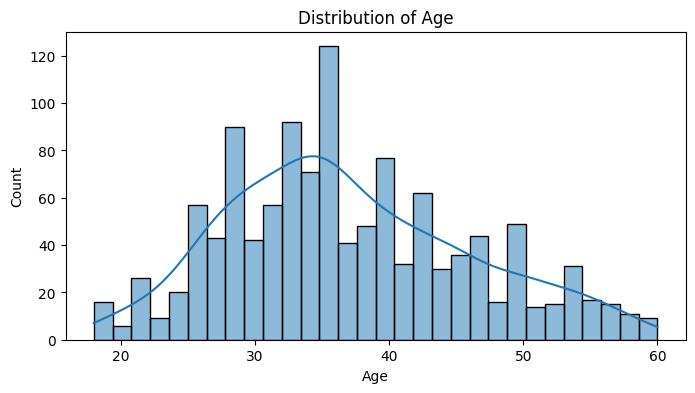

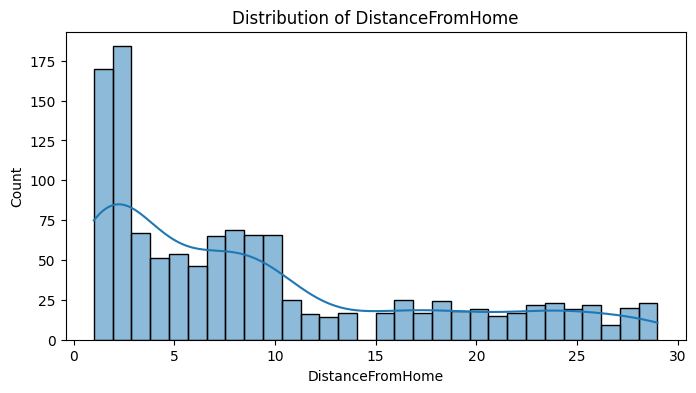

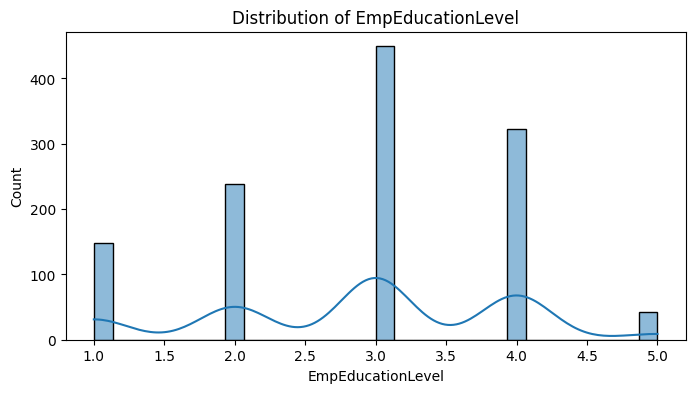

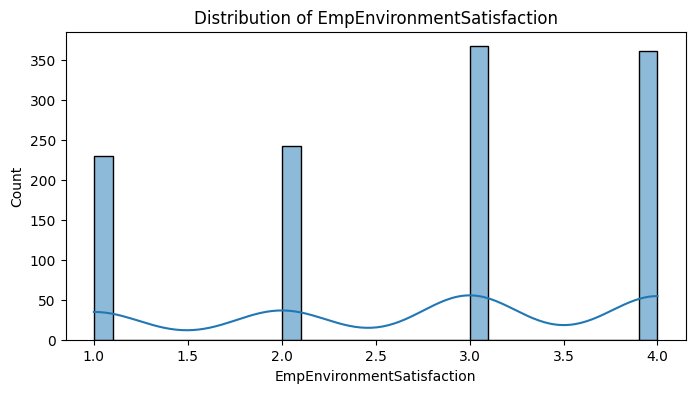

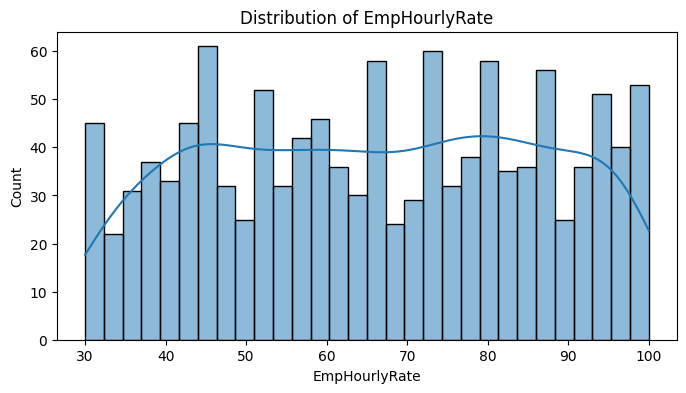

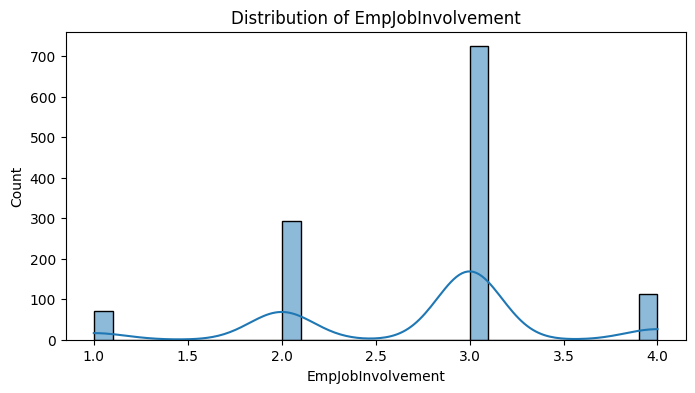

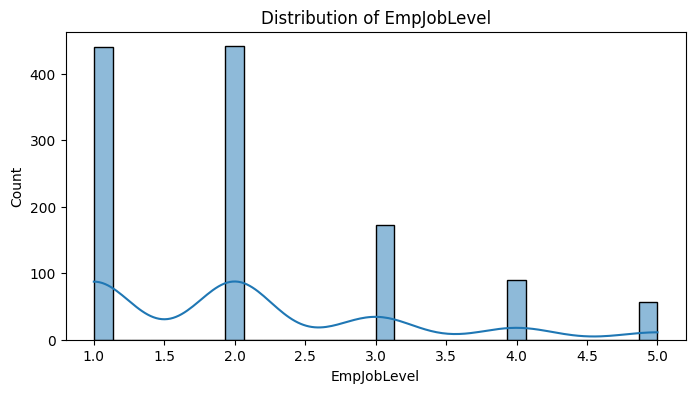

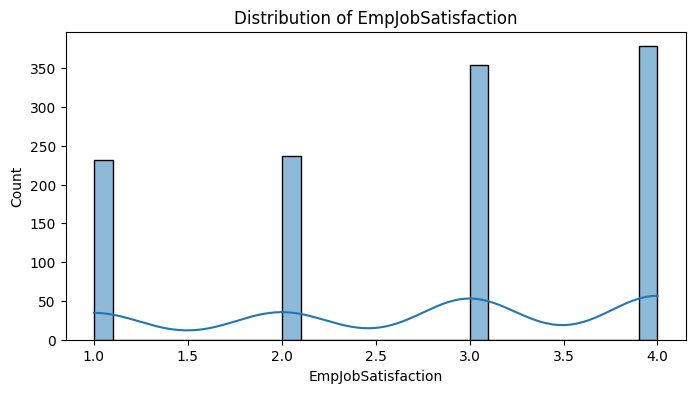

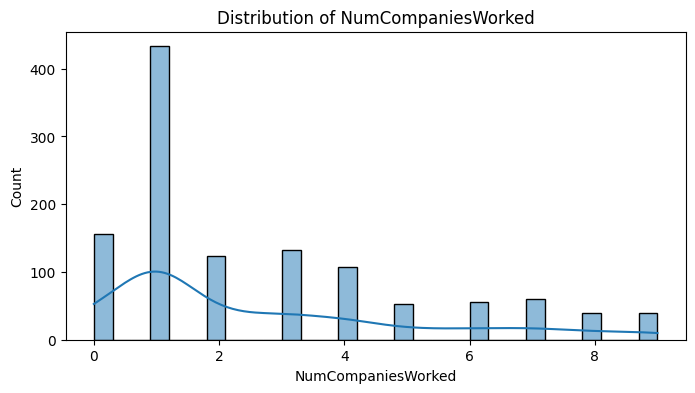

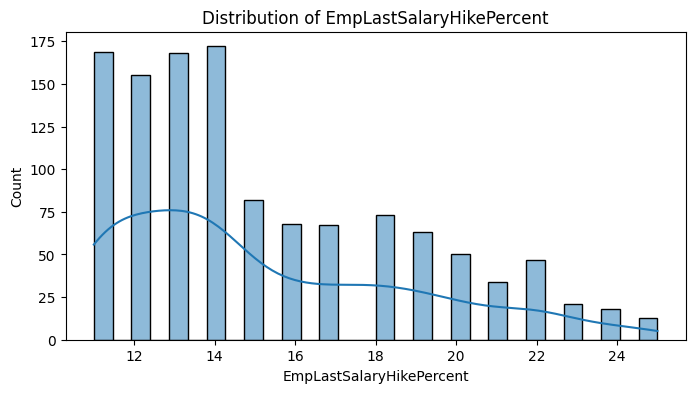

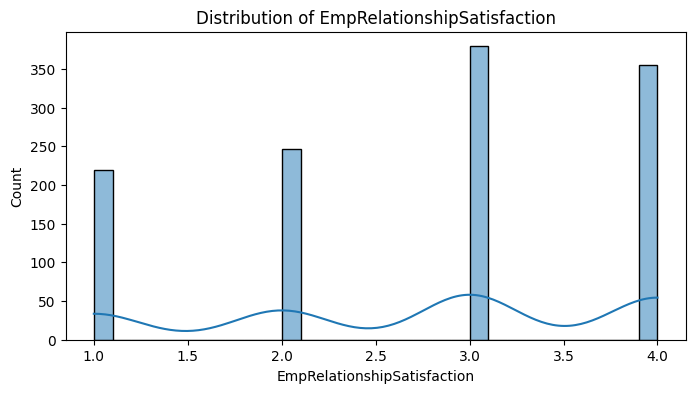

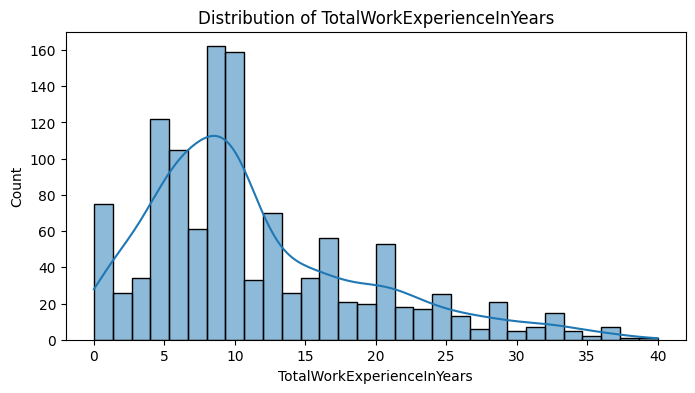

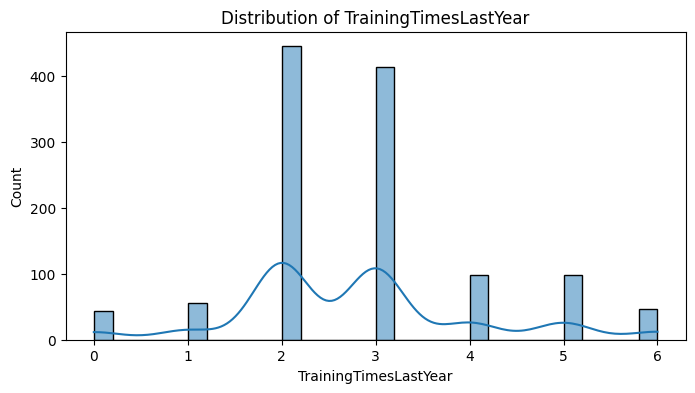

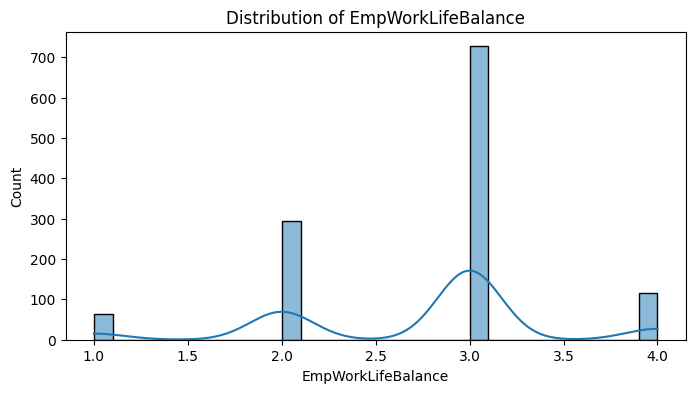

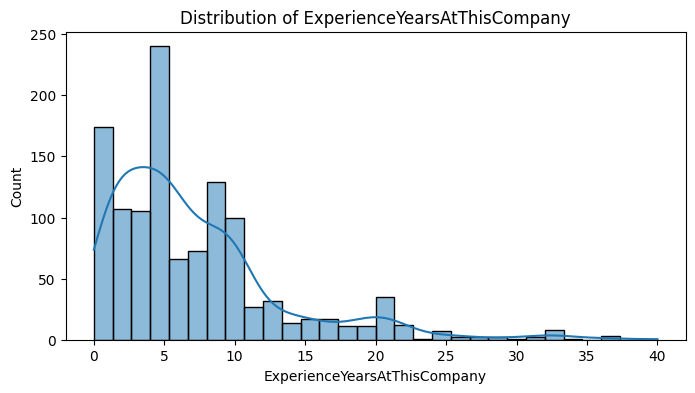

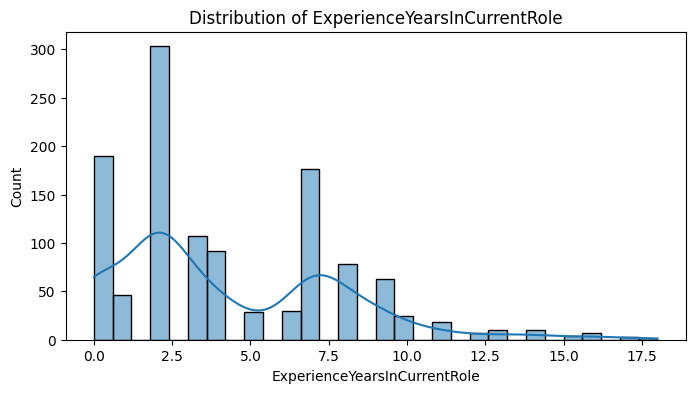

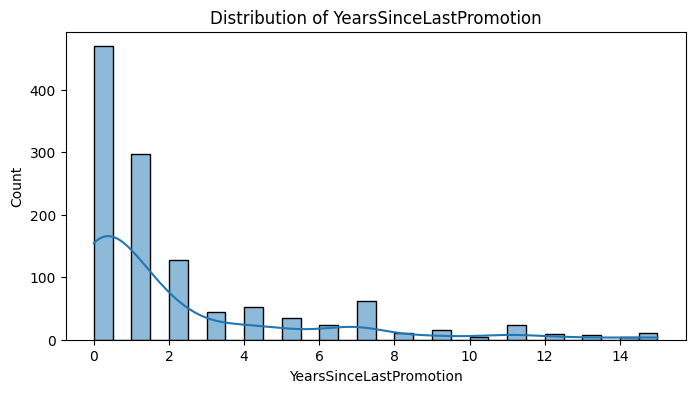

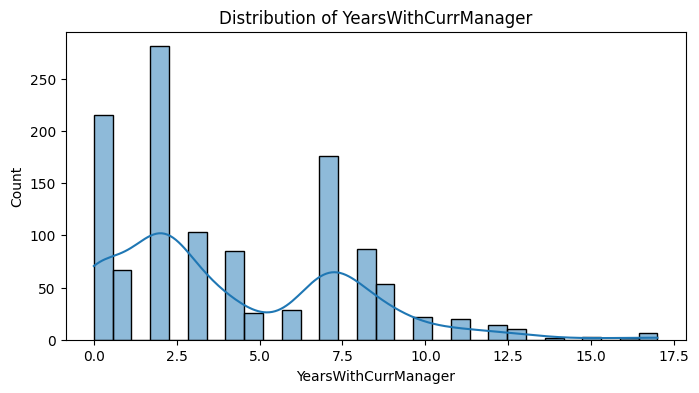

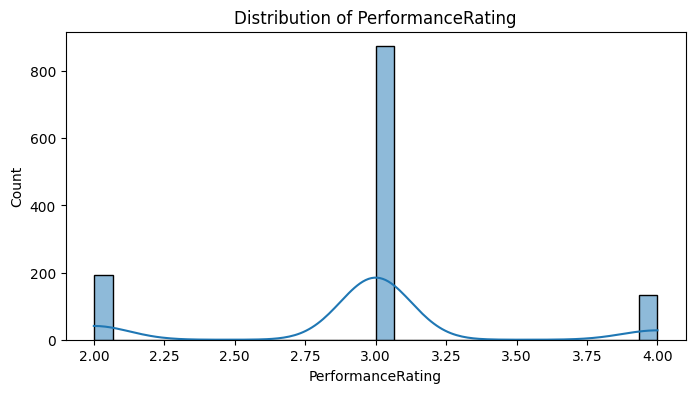

In [ ]:
for col in num_col:
  plt.figure(figsize=(8,4))
  sns.histplot(data[col],kde=True,bins=30)
  plt.title(f'Distribution of {col}')

  plt.show()

Histograms are generated for all numerical columns to visualize their distributions. This helps in understanding skewness, presence of outliers, and overall shape of the data for each numerical feature.

### Performance Rating Distribution

This count plot visualizes the distribution of `PerformanceRating`, showing how many employees fall into each rating category. This gives insight into the target variable's class balance.

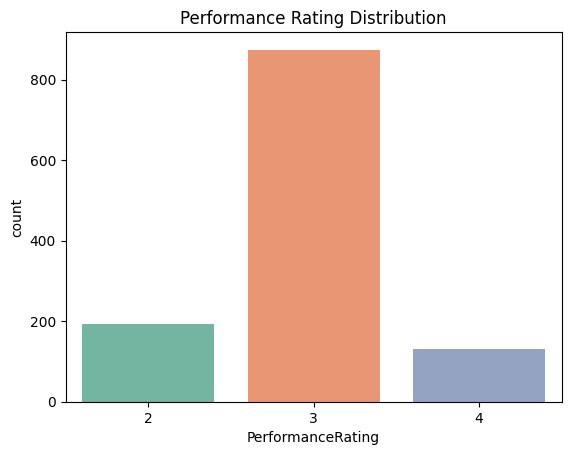

In [ ]:
sns.countplot(x='PerformanceRating', data=data, palette='Set2')
plt.title('Performance Rating Distribution')
plt.show()

In [ ]:
dept_performance = data.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values()
dept_performance

EmpDepartment
Finance                   2.775510
Sales                     2.860590
Research & Development    2.921283
Human Resources           2.925926
Data Science              3.050000
Development               3.085873
Name: PerformanceRating, dtype: float64

### Department-wise Performance

Here, we calculate the average `PerformanceRating` for each `EmpDepartment` and sort them to see which departments tend to have higher or lower performance. The raw series `dept_performance` is displayed first.

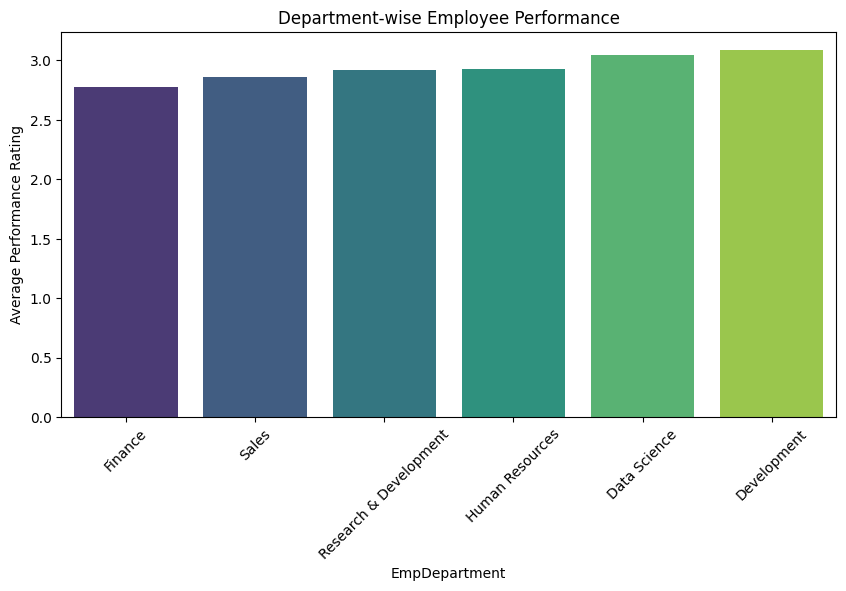

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=dept_performance.index, y=dept_performance.values, palette="viridis")
plt.title("Department-wise Employee Performance")
plt.xticks(rotation=45)
plt.ylabel("Average Performance Rating")
plt.xlabel("EmpDepartment")
plt.show()

A bar plot is used to visualize the average performance rating across different departments. This provides a clear comparison of performance levels between departments.

### Missing Value Check

This step checks for any missing values across all columns. The output shows that there are no missing values in this dataset, which simplifies the data cleaning process.

In [ ]:
print("Missing Values:", data.isnull().sum())

Missing Values: EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64


### Feature Correlation Heatmap

A heatmap of the correlation matrix is generated to visualize the relationships between all features. This helps identify highly correlated features, which might indicate multicollinearity, and also shows features that are strongly correlated with the `PerformanceRating`.

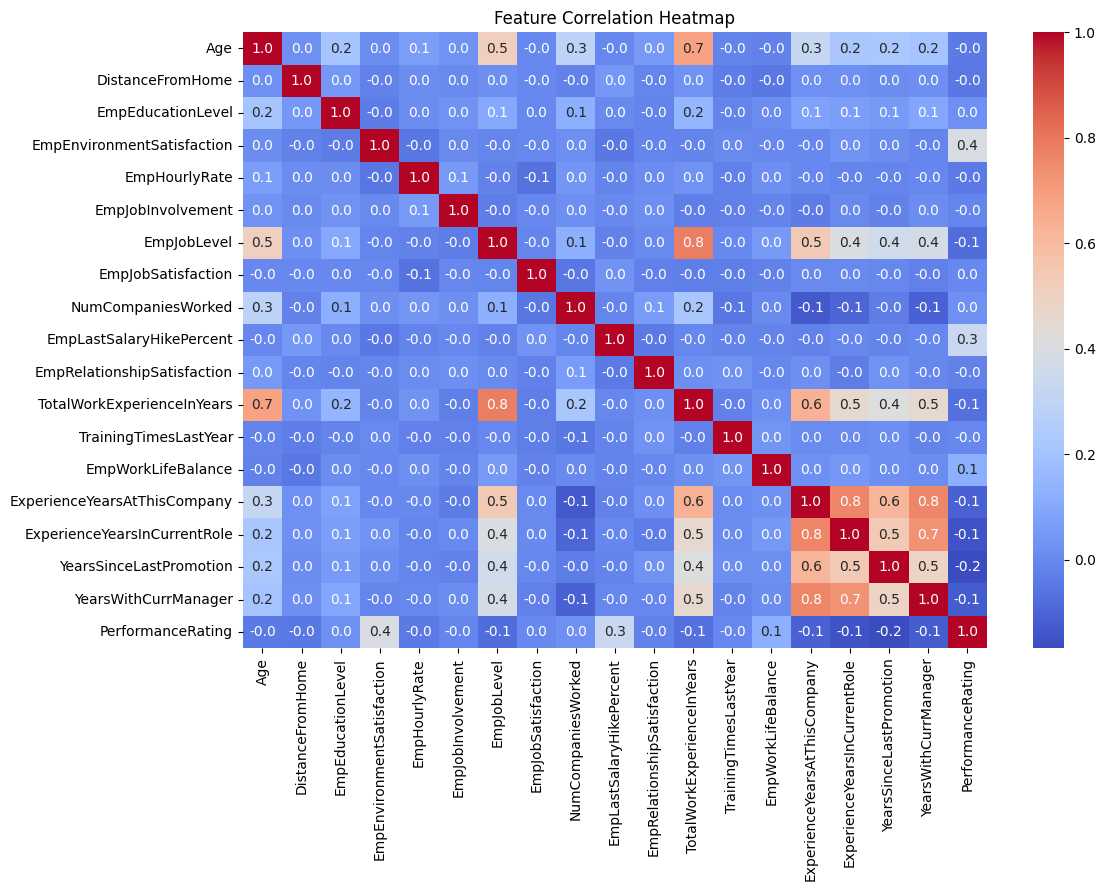

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm',fmt='.1f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Outlier Check via Boxplots

Boxplots of all numeric columns are plotted side by side to visually flag features with a wide spread or potential outliers before they are scaled and fed into the models.

<Axes: >

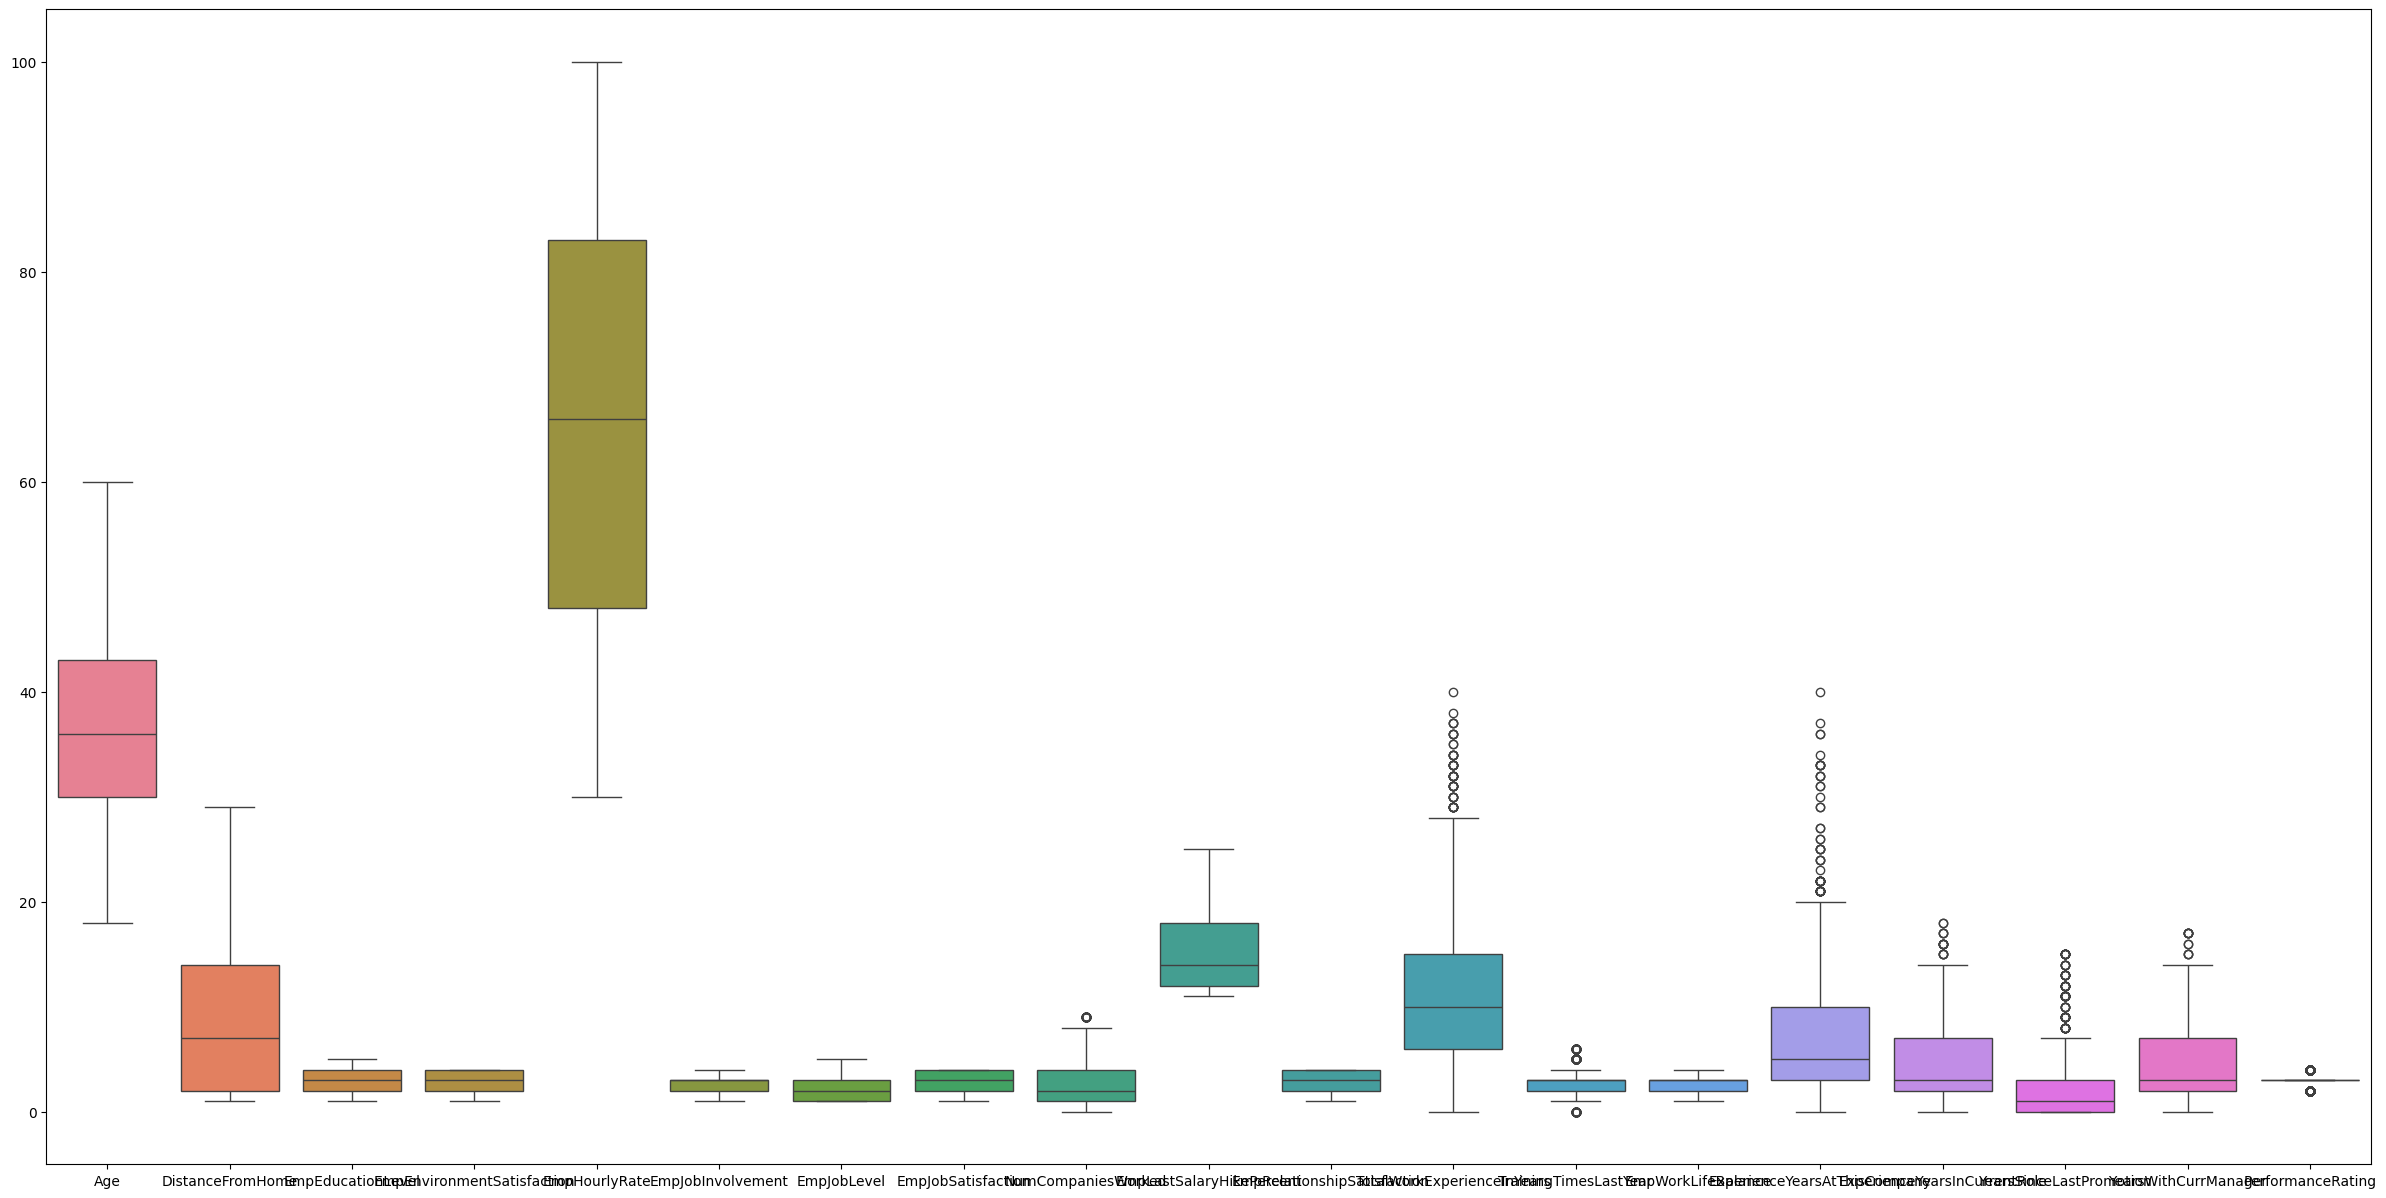

In [ ]:
plt.figure(figsize=(30,15))
sns.boxplot(data)

In [ ]:
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

## 4. Data Preprocessing

### Label Encoding Categorical Features

All object-type (categorical) columns are converted into numerical representations using `LabelEncoder`. This is a necessary step before feeding the data into most machine learning models. The `label_encoders` dictionary stores the fitted encoders for potential inverse transformations later.

In [ ]:
# Splitting Data
X = data.drop(columns=['PerformanceRating'])  # Target variable assumed
y = data['PerformanceRating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# class distribution BEFORE SMOTE
print('Class distribution before SMOTE:')
print(y_train.value_counts())
print(f'\nTotal training samples: {len(y_train)}')

Class distribution before SMOTE:
PerformanceRating
3    690
2    165
4    105
Name: count, dtype: int64

Total training samples: 960


In [ ]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

y_train_balanced.value_counts()

PerformanceRating
2    690
3    690
4    690
Name: count, dtype: int64

## 5. Dimensionality Reduction: Principal Component Analysis

Principal Component Analysis is a technique used to reduce the dimensionality of a dataset while retaining as much information as possible. It transforms the original features into a new set of orthogonal (uncorrelated) variables called principal components. This can help in visualizing high-dimensional data, reducing noise, and improving the performance of machine learning models by dealing with multicollinearity.

In [ ]:
# Feature Reduction using PCA
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test_scaled)


After applying PCA, the 26 original features are reduced to 10 principal components, which together retain approximately 61.5% of the total variance in the data. This is a deliberate trade-off: some information is lost, but the reduced, decorrelated feature set is faster to train on and less prone to overfitting for the SVM and Neural Network models in particular.

Model training below uses these reduced-dimension datasets (`X_train_pca`, `X_test_pca`) together with the SMOTE-balanced target (`y_train_balanced`) and the original, untouched test labels (`y_test`).

## 6. Model Training

Three classifiers from different model families are trained and compared on the PCA-reduced, SMOTE-balanced training data: a **Random Forest** (tree ensemble, handles non-linear interactions and is robust to scaling), a **Support Vector Machine** with an RBF kernel (strong on smaller, well-scaled feature spaces), and a **Neural Network** (Multi-Layer Perceptron, capable of learning more complex non-linear boundaries). Comparing across families helps confirm that any result is about the data, not an artifact of one algorithm's bias.

In [ ]:
# Train ML Models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42)
}
for name, model in models.items():
    model.fit(X_train_pca, y_train_balanced)
    y_pred = model.predict(X_test_pca)
    print(f'\nModel: {name}')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
    print('Classification Report:\n', classification_report(y_test, y_pred))


Model: Random Forest
Accuracy: 0.7541666666666667
Confusion Matrix:
 [[ 13  15   1]
 [ 24 149  11]
 [  0   8  19]]
Classification Report:
               precision    recall  f1-score   support

           2       0.35      0.45      0.39        29
           3       0.87      0.81      0.84       184
           4       0.61      0.70      0.66        27

    accuracy                           0.75       240
   macro avg       0.61      0.65      0.63       240
weighted avg       0.78      0.75      0.76       240




Model: SVM
Accuracy: 0.6666666666666666
Confusion Matrix:
 [[ 14  14   1]
 [ 41 128  15]
 [  0   9  18]]
Classification Report:
               precision    recall  f1-score   support

           2       0.25      0.48      0.33        29
           3       0.85      0.70      0.76       184
           4       0.53      0.67      0.59        27

    accuracy                           0.67       240
   macro avg       0.54      0.62      0.56       240
weighted avg       0.74      0.67      0.69       240




Model: Neural Network
Accuracy: 0.7333333333333333
Confusion Matrix:
 [[ 15  12   2]
 [ 27 143  14]
 [  0   9  18]]
Classification Report:
               precision    recall  f1-score   support

           2       0.36      0.52      0.42        29
           3       0.87      0.78      0.82       184
           4       0.53      0.67      0.59        27

    accuracy                           0.73       240
   macro avg       0.59      0.65      0.61       240
weighted avg       0.77      0.73      0.75       240



On the held-out test set, the baseline models score **75.4%** (Random Forest), **73.3%** (Neural Network), and **66.7%** (SVM) accuracy. Random Forest is the strongest performer before any tuning.

## 7. Hyperparameter Tuning

Each model is re-trained inside a 5-fold `GridSearchCV` to search over a small grid of its key hyperparameters (e.g., tree depth and count for Random Forest; `C`/`gamma`/`kernel` for SVM; hidden-layer size and regularization strength for the Neural Network), selecting the combination with the best cross-validated accuracy.

In [ ]:
# Hyperparameter tuning parameters
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}
param_grid_nn = {
    'hidden_layer_sizes': [(50, 50), (100, 50)],
    'max_iter': [300, 500],
    'alpha': [0.0001, 0.001]
}

# Define Models
models = {
    'Random Forest': GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy'),
    'SVM': GridSearchCV(SVC(probability=True), param_grid_svm, cv=5, scoring='accuracy'),
    'Neural Network': GridSearchCV(MLPClassifier(random_state=42), param_grid_nn, cv=5, scoring='accuracy')
}

# store each tuned model + its test accuracy so later cells can reference "the best one" explicitly
tuned_results = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train_balanced)
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    tuned_results[name] = {'model': best_model, 'accuracy': acc, 'params': model.best_params_}
    print(f'\nBest Model: {name}')
    print('Best Parameters:', model.best_params_)
    print('Accuracy:', acc)
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
    print('Classification Report:\n', classification_report(y_test, y_pred))


Best Model: Random Forest
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 0.7541666666666667
Confusion Matrix:
 [[ 13  15   1]
 [ 24 149  11]
 [  0   8  19]]
Classification Report:
               precision    recall  f1-score   support

           2       0.35      0.45      0.39        29
           3       0.87      0.81      0.84       184
           4       0.61      0.70      0.66        27

    accuracy                           0.75       240
   macro avg       0.61      0.65      0.63       240
weighted avg       0.78      0.75      0.76       240




Best Model: SVM
Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Accuracy: 0.6916666666666667
Confusion Matrix:
 [[ 10  18   1]
 [ 27 142  15]
 [  0  13  14]]
Classification Report:
               precision    recall  f1-score   support

           2       0.27      0.34      0.30        29
           3       0.82      0.77      0.80       184
           4       0.47      0.52      0.49        27

    accuracy                           0.69       240
   macro avg       0.52      0.55      0.53       240
weighted avg       0.71      0.69      0.70       240




Best Model: Neural Network
Best Parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'max_iter': 500}
Accuracy: 0.7208333333333333
Confusion Matrix:
 [[ 11  17   1]
 [ 25 147  12]
 [  0  12  15]]
Classification Report:
               precision    recall  f1-score   support

           2       0.31      0.38      0.34        29
           3       0.84      0.80      0.82       184
           4       0.54      0.56      0.55        27

    accuracy                           0.72       240
   macro avg       0.56      0.58      0.57       240
weighted avg       0.74      0.72      0.73       240



Tuning lifts SVM to **69.2%** and leaves Random Forest unchanged at **75.4%** (its default-ish settings were already close to optimal), while the Neural Network settles at **72.1%**. **Random Forest remains the best overall model** and is carried forward as `best_model` below.

## 8. Sample Prediction

As a sanity check, and to mirror the intended hiring-support use case, the best-performing tuned model is used to score a single unseen record from the test set and the prediction is compared against the employee's actual recorded rating.

In [ ]:
# pick the best-performing tuned model rather than relying on a leftover loop variable
best_name = max(tuned_results, key=lambda k: tuned_results[k]['accuracy'])
best_model = tuned_results[best_name]['model']
print(f"Using best model: {best_name} (test accuracy={tuned_results[best_name]['accuracy']:.2f})")

new_employee = X_test_pca[[0], :] if isinstance(X_test_pca, np.ndarray) else X_test_pca.iloc[[0]]
predicted_performance = best_model.predict(new_employee)
print(f"Predicted Performance Rating for New Employee: {predicted_performance[0]}")
print(f"Actual Performance Rating: {y_test.iloc[0]}")

Using best model: Random Forest (test accuracy=0.75)
Predicted Performance Rating for New Employee: 3
Actual Performance Rating: 3


## 9. Project Summary

**Algorithm and training method.** Three classifiers were trained and compared: Random Forest, Support Vector Machine (RBF kernel), and a Neural Network (Multi-Layer Perceptron). Data was split 80/20 (stratified by the target), scaled with `StandardScaler`, rebalanced on the training fold only with SMOTE (to avoid leaking test information), and reduced to 10 components with PCA before training. Each model was then re-tuned with 5-fold `GridSearchCV`. The tuned Random Forest was the best performer, at 75.4% test accuracy.

**Most important features.** Ranked by correlation with `PerformanceRating`: `EmpEnvironmentSatisfaction` (0.40), `EmpLastSalaryHikePercent` (0.33), and `YearsSinceLastPromotion` (0.17). These are computed on the original, pre-PCA features deliberately — PCA's components are linear blends of all features, so the model's internal importances live in component space and can't be mapped cleanly back to a single original column. PCA was used purely to reduce dimensionality/noise for training, not for feature interpretation.

**Other techniques and tools.** `pandas`/`numpy` for data handling; `seaborn`/`matplotlib` for exploratory visualization; `scikit-learn`'s `LabelEncoder` and `StandardScaler` for preprocessing; `imbalanced-learn`'s `SMOTE` for class balancing; `scikit-learn`'s `PCA` for dimensionality reduction; and `GridSearchCV` for hyperparameter tuning.

## 10. Feature Selection and Engineering

**Important features and why.** The three strongest correlates of performance rating (`EmpEnvironmentSatisfaction`, `EmpLastSalaryHikePercent`, `YearsSinceLastPromotion`) all describe how an employee is currently being treated or recognized, rather than fixed personal traits — which suggests performance is something the organization can actively influence, not just something it can predict.

**Feature transformations.** Categorical columns were label-encoded; numeric columns were standardized (zero mean, unit variance), which is required before PCA and helps both SVM and the Neural Network converge properly; PCA then compressed the encoded feature set to 10 components.

**Correlation and interactions.** The correlation heatmap surfaces the expected tenure cluster — `ExperienceYearsAtThisCompany`, `ExperienceYearsInCurrentRole`, and `YearsWithCurrManager` all move together, since they're different cuts of the same underlying work history. Rather than manually dropping redundant columns, PCA's decorrelation step absorbs this overlap automatically.

In [ ]:
# Compute correlation matrix
correlation_matrix = data.corr(numeric_only=True)

# correlation of each feature with PerformanceRating
performance_corr = correlation_matrix['PerformanceRating'].drop('PerformanceRating').abs().sort_values(ascending=False)

# Select top 3 most correlated features
top_factors = performance_corr.head(3)

# Display the top 3 factors
print("Top 3 Important Factors Affecting Employee Performance:\n", top_factors)

Top 3 Important Factors Affecting Employee Performance:
 EmpEnvironmentSatisfaction    0.395561
EmpLastSalaryHikePercent      0.333722
YearsSinceLastPromotion       0.167629
Name: PerformanceRating, dtype: float64


## 11. Results, Analysis and Insights

**A relationship not covered above.** Department headcount doesn't predict risk — Development has roughly 3x the staff of Finance but a far smaller share of low performers ("2"-rated): about 4% versus 31% in Finance and 23% in Sales. Underperformance is concentrated, not evenly spread.

**Most important technique used.** SMOTE mattered more than any single algorithm choice. Roughly 72% of employees are rated "3", so a model that ignored the imbalance could hit ~72% accuracy by predicting the majority class every time, while being useless at flagging the "2" and "4" employees that actually matter for HR decisions. After balancing, the tuned Random Forest still only reaches 45% recall on rating "2" and 70% on rating "4" (versus 81% on the majority class "3") — real progress over a majority-only baseline, but a genuine limitation worth stating plainly: this model is not yet reliable enough, on its own, to flag low performers with confidence.

**Answers to the business problems.**
1. *Department-wise performance:* Development and Data Science perform best; Finance and Sales are weakest, with the highest concentration of low ratings.
2. *Top 3 factors:* environment satisfaction, recent salary hike, and time since last promotion.
3. *Predictive model:* the tuned Random Forest reaches 75.4% overall accuracy, but performance is uneven across classes — strong on typical ("3") performers, weaker on the minority classes. It's reasonable as an internal screening aid, not yet strong enough to be the sole basis for a hiring or termination decision.

**Further business insight.** The link between salary hike and rating likely runs both ways — many companies size the raise off the review score itself — so it shouldn't be read as proof that bigger raises alone would cause better performance without further testing.

## 12. Recommendations

- **Prioritize Finance and Sales** for intervention — they carry the highest concentration of low performers and are the most plausible source of the client-satisfaction decline.
- **Build a structured promotion/career-pathing cadence**; flag anyone past ~3 years without a promotion or role change, since promotion recency was one of the three strongest predictors and is directly within the company's control.
- **Run environment-satisfaction pulse checks at the team/manager level**, not just company-wide, to localize exactly where dissatisfaction is concentrated.
- **Use the model as a quarterly internal screening tool, not a hiring gate** — frame it as a coaching trigger rather than a penalty, given its weaker reliability on the minority classes.
- **Make salary-hike criteria transparent**; since hikes and ratings move together, a clear, visible link between the two makes the raise function as a genuine motivator rather than an opaque reward.